In [23]:
pip install torch transformers


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
path = "sp500_headlines_2008_2024.csv"
headline_df = pd.read_csv(path).drop(columns=["CP"])
headline_df["aligned_date"] = pd.to_datetime(headline_df["Date"]) + pd.offsets.MonthBegin(1)
headline_df.sort_values("Date", inplace=True)
headline_df.head(20)

,Title,Date,aligned_date
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,2008-02-01
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,2008-02-01
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,2008-02-01
8,It's a Black Monday as stock markets tank in e...,2008-01-22,2008-02-01
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,2008-02-01


In [25]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54180.92it/s]


In [26]:
headlines = headline_df["Title"].tolist()
classification = classifier(headlines, top_k=None)

In [27]:
pos_scores = []
neg_scores = []
neu_scores = []

for results in classification:
    score_dict = {result["label"]: result["score"] for result in results}
    pos_scores.append(score_dict.get("positive", 0))
    neg_scores.append(score_dict.get("negative", 0))
    neu_scores.append(score_dict.get("neutral", 0))

headline_df["Pos_Score"] = pos_scores
headline_df["Neg_Score"] = neg_scores
headline_df["Neu_Score"] = neu_scores

output_path = "sp500_headlines_2008_2024_with_sentiment.csv"
headline_df.to_csv(output_path, index=False)
headline_df.head(20)

,Title,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01,0.188399,0.604176,0.207425
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01,0.011426,0.962149,0.026425
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01,0.052938,0.122815,0.824247
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01,0.861627,0.064192,0.074181
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01,0.586567,0.165055,0.248378
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,2008-02-01,0.082773,0.014693,0.902534
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,2008-02-01,0.024102,0.843392,0.132506
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,2008-02-01,0.542340,0.282442,0.175218
8,It's a Black Monday as stock markets tank in e...,2008-01-22,2008-02-01,0.025481,0.926721,0.047798
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,2008-02-01,0.446016,0.516208,0.037776


In [28]:
headline_df = pd.read_csv("sp500_headlines_2008_2024_with_sentiment.csv", 
    parse_dates=["Date","aligned_date"])
headline_df

,Title,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01,0.188399,0.604176,0.207425
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01,0.011426,0.962149,0.026425
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01,0.052938,0.122815,0.824247
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01,0.861627,0.064192,0.074181
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01,0.586567,0.165055,0.248378
...,...,...,...,...,...,...
19122,REITs vs. Stocks: What Does the Data Say?,2024-03-04,2024-04-01,0.035319,0.142745,0.821936
19123,"Nasdaq Index, Dow Jones, S&P 500 News: Futures...",2024-03-04,2024-04-01,0.045620,0.907880,0.046500
19124,"Nasdaq 100, Dow Jones, S&P 500 News: Cautious ...",2024-03-04,2024-04-01,0.105398,0.267573,0.627029
19125,"Bank of America boosts S&P 500 target to 5,400...",2024-03-04,2024-04-01,0.157201,0.015896,0.826903


In [29]:
mean_sentiment = headline_df.groupby(["Date", "aligned_date"])[["Pos_Score", "Neg_Score", "Neu_Score"]].mean().reset_index()

We will aggregate these daily scores into a rolling 30-day sentiment index using an Exponential Moving Average (EMA) and create a "Neutrality Ratio" to cut through the noise of neutral financial journalism.
- The Neutrality Ratio Filter: Financial headlines often state dry facts, causing FinBERT to output high "Neutral" probabilities. We have to filter this to show only directional bias.
    - By calculating `Positive / (Positive + Negative)`, it isolates the directional bias by answering the question: Of the sentiment that actually took a stance, how much of it was positive?
- EMA: Markets react to recent news much more violently than month-old news, so we use an EMA rather than an SMA to look at the score

In [30]:
mean_sentiment["Neutrality_Ratio"]= (mean_sentiment["Pos_Score"]/(mean_sentiment["Pos_Score"]+mean_sentiment["Neg_Score"])).fillna(0.5)
mean_sentiment["Pos_Score_30day_EMA"] = mean_sentiment["Pos_Score"].ewm(span=30, adjust=False).mean()
mean_sentiment["Neg_Score_30day_EMA"] = mean_sentiment["Neg_Score"].ewm(span=30, adjust=False).mean()
mean_sentiment["Neutrality_Ratio_30day_EMA"] = mean_sentiment["Neutrality_Ratio"].ewm(span=30, adjust=False).mean()
mean_sentiment.drop_duplicates(subset='aligned_date', keep='last',inplace=True)
mean_sentiment

,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score,Neutrality_Ratio,Pos_Score_30day_EMA,Neg_Score_30day_EMA,Neutrality_Ratio_30day_EMA
7,2008-01-30,2008-02-01,0.096287,0.016126,0.887587,0.856544,0.164449,0.481827,0.266188
14,2008-02-29,2008-03-01,0.020833,0.947423,0.031744,0.021516,0.124942,0.459353,0.295600
20,2008-03-27,2008-04-01,0.011984,0.959217,0.028799,0.012340,0.142335,0.497481,0.299145
27,2008-04-25,2008-05-01,0.338670,0.293752,0.367578,0.535513,0.139617,0.478218,0.310837
37,2008-05-29,2008-06-01,0.072870,0.902726,0.024404,0.074693,0.157693,0.448432,0.363876
...,...,...,...,...,...,...,...,...,...
3443,2023-11-30,2023-12-01,0.390927,0.294099,0.314974,0.570675,0.288294,0.368613,0.436345
3463,2023-12-29,2024-01-01,0.286357,0.419801,0.293842,0.405514,0.320061,0.304784,0.513559
3484,2024-01-31,2024-02-01,0.134494,0.377243,0.488262,0.262819,0.306004,0.343688,0.463749
3504,2024-02-29,2024-03-01,0.335937,0.273130,0.390934,0.551560,0.341223,0.302135,0.523062


In [31]:
from fredapi import Fred
from dotenv import load_dotenv
import os
load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred_auth = fred = Fred(api_key=FRED_API_KEY)
recession_data = pd.DataFrame(fred_auth.get_series("USREC")).reset_index().rename(columns={"index": "aligned_date", 0: "recession"})
recession_data = recession_data[recession_data['aligned_date'] >= pd.to_datetime('2001-01-01')]
recession_data["period_rolling_recession"]= recession_data["recession"].rolling(window=6, min_periods=1).max().shift(-6)
recession_data[["aligned_date","period_rolling_recession"]].dropna()

,aligned_date,period_rolling_recession
1753,2001-01-01,1.0
1754,2001-02-01,1.0
1755,2001-03-01,1.0
1756,2001-04-01,1.0
1757,2001-05-01,1.0
...,...,...
2046,2025-06-01,0.0
2047,2025-07-01,0.0
2048,2025-08-01,0.0
2049,2025-09-01,0.0


In [32]:

feature_data = pd.merge(
    mean_sentiment, 
    recession_data[["aligned_date","period_rolling_recession"]].dropna(), 
    on='aligned_date', 
    how='left'
)
feature_data.drop(columns=["Date","Pos_Score","Neg_Score","Neu_Score","Neutrality_Ratio"], inplace= True)
feature_data = feature_data.dropna()
feature_data.dropna()
output_path = "sentiment_training_data_features.csv"
feature_data.to_csv(output_path, index=False)

At this point we've running into an issue: The Mismatched History Problem. There is a different period of data sets that is available to us.

The "Test Set" Golden Rule
- In a head-to-head evaluation or an ensemble, the models are competing to see how they handle "unseen" data. 
- We have to make sure they test on the same unseen data to ensure a fair test.

To tackle this: 
- Macro Model: Trained on 2001–2015. Tested on 2016–Present.
- Sentiment Model: Train on 2008–2015. Test on 2016–Present.

In [33]:
pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
phase_1_split_aligned_date = "2016-07-01"
training_data = feature_data[feature_data["aligned_date"]<phase_1_split_aligned_date] 
testing_data = feature_data[feature_data["aligned_date"]>=phase_1_split_aligned_date]
training_x = training_data.drop(columns=['period_rolling_recession','aligned_date'])
training_y = training_data['period_rolling_recession']
testing_x = testing_data.drop(columns=['period_rolling_recession','aligned_date'])
testing_y = testing_data['period_rolling_recession']

ratio = (training_y == 0).sum() / (training_y == 1).sum()
print(f"Calculated scale_pos_weight: {ratio:.2f}")

Calculated scale_pos_weight: 5.31


In [35]:
lightgbm_model = LGBMClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

In [36]:
# mac conflict
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [37]:
lightgbm_model.fit(training_x, training_y)
y_lightgbm_pred = lightgbm_model.predict(testing_x)

[LightGBM] [Info] Number of positive: 16, number of negative: 85
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 105
[LightGBM] [Info] Number of data points in the train set: 101, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158416 -> initscore=-1.670063
[LightGBM] [Info] Start training from score -1.670063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [38]:
print("\nClassification Report for LightGBM:")
print(classification_report(testing_y, y_lightgbm_pred))


Classification Report for LightGBM:
              precision    recall  f1-score   support

         0.0       0.90      0.71      0.79        87
         1.0       0.00      0.00      0.00         7

    accuracy                           0.66        94
   macro avg       0.45      0.36      0.40        94
weighted avg       0.83      0.66      0.74        94



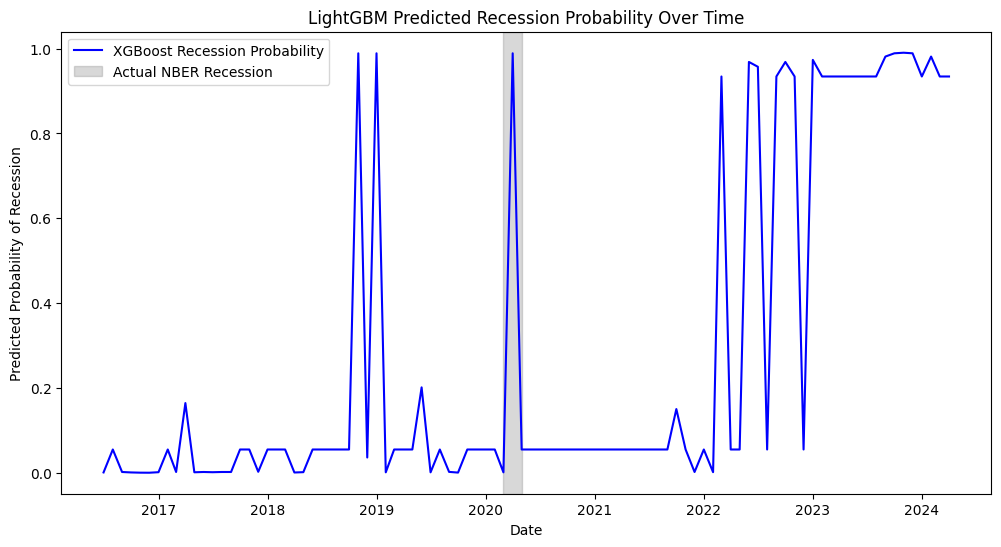

In [39]:
y_lightgbm_probs_all = lightgbm_model.predict_proba(testing_x)
y_recession_probs = y_lightgbm_probs_all [:, 1]
lightgbm_proba_table = testing_data[['aligned_date']].copy()
lightgbm_proba_table['y_recession_prob'] = y_recession_probs
lightgbm_proba_table = pd.merge(
    lightgbm_proba_table, 
    recession_data, 
    on='aligned_date', 
    how='left'
)

lightgbm_proba_table['change'] = lightgbm_proba_table['recession'].diff()
starts = lightgbm_proba_table[lightgbm_proba_table['change'] == 1]['aligned_date'].tolist()
ends = lightgbm_proba_table[lightgbm_proba_table['change'] == -1]['aligned_date'].tolist()
if lightgbm_proba_table['recession'].iloc[0] == 1:
    starts.insert(0, lightgbm_proba_table['aligned_date'].iloc[0])
if lightgbm_proba_table['recession'].iloc[-1] == 1:
    ends.append(lightgbm_proba_table['aligned_date'].iloc[-1])
    
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(lightgbm_proba_table['aligned_date'], lightgbm_proba_table['y_recession_prob'], 
         label='XGBoost Recession Probability', color='blue')

for s, e in zip(starts, ends):
    plt.axvspan(s, e, color='gray', alpha=0.3, label='Actual NBER Recession')
plt.title('LightGBM Predicted Recession Probability Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()

In [40]:
lightgbm_proba_table.head(20)
auc = roc_auc_score(testing_y, lightgbm_proba_table["y_recession_prob"])
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.3005


In [41]:
import joblib
joblib.dump(lightgbm_model, 'soft_model.joblib')

['soft_model.joblib']

### Reconducting this process by aggregating by week rather than by month

Calculated scale_pos_weight: 5.32
[LightGBM] [Info] Number of positive: 69, number of negative: 367
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158257 -> initscore=-1.671255
[LightGBM] [Info] Start training from score -1.671255
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

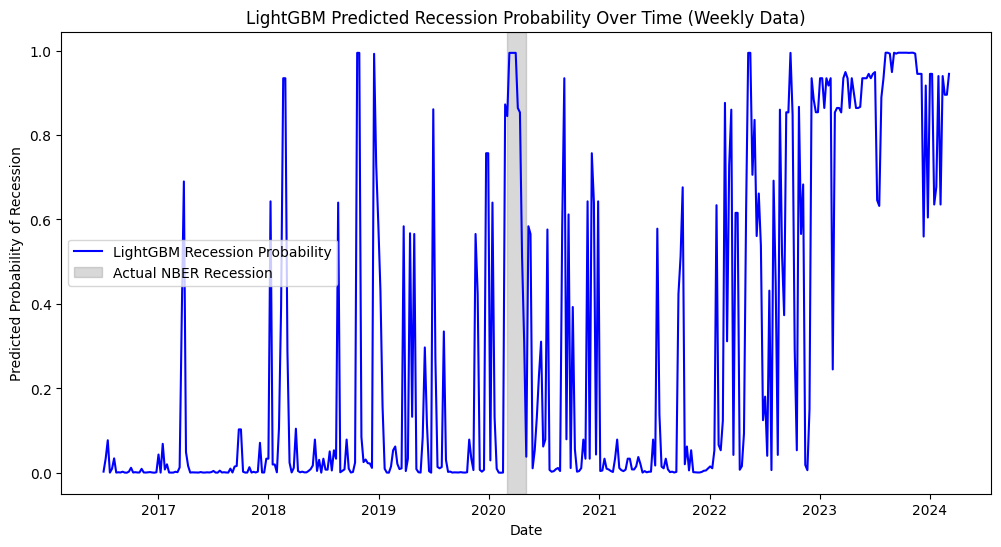

In [6]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SPLIT DATA INTO TRAIN AND TEST SETS
# ---------------------------------------------------------
phase_1_split_aligned_date = "2016-07-01"

# Use the new 'aligned_week' for the split instead of aligned_date
training_data = feature_data[feature_data["aligned_week"] < phase_1_split_aligned_date] 
testing_data = feature_data[feature_data["aligned_week"] >= phase_1_split_aligned_date]

# Drop the target variable and the date column from the feature sets
training_x = training_data.drop(columns=['period_rolling_recession', 'aligned_week'])
training_y = training_data['period_rolling_recession']

testing_x = testing_data.drop(columns=['period_rolling_recession', 'aligned_week'])
testing_y = testing_data['period_rolling_recession']

# Calculate class imbalance ratio for LightGBM
ratio = (training_y == 0).sum() / (training_y == 1).sum()
print(f"Calculated scale_pos_weight: {ratio:.2f}")

# ---------------------------------------------------------
# TRAIN THE LIGHTGBM MODEL
# ---------------------------------------------------------
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

lightgbm_model = LGBMClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

lightgbm_model.fit(training_x, training_y)

# ---------------------------------------------------------
# EVALUATE THE MODEL
# ---------------------------------------------------------
y_lightgbm_pred = lightgbm_model.predict(testing_x)

print("\nClassification Report for LightGBM:")
print(classification_report(testing_y, y_lightgbm_pred))

y_lightgbm_probs_all = lightgbm_model.predict_proba(testing_x)
y_recession_probs = y_lightgbm_probs_all[:, 1]

auc = roc_auc_score(testing_y, y_recession_probs)
print(f"ROC-AUC Score: {auc:.4f}")

# ---------------------------------------------------------
# PREPARE DATA FOR PLOTTING
# ---------------------------------------------------------

lightgbm_proba_table = testing_data[['aligned_week']].copy()
lightgbm_proba_table['y_recession_prob'] = y_recession_probs

lightgbm_proba_table['month_start'] = lightgbm_proba_table['aligned_week'].dt.to_period('M').dt.start_time

lightgbm_proba_table = pd.merge(
    lightgbm_proba_table, 
    recession_data, 
    on='month_start', 
    how='left'
)

lightgbm_proba_table['change'] = lightgbm_proba_table['recession'].diff()

starts = lightgbm_proba_table[lightgbm_proba_table['change'] == 1]['aligned_week'].tolist()
ends = lightgbm_proba_table[lightgbm_proba_table['change'] == -1]['aligned_week'].tolist()

if lightgbm_proba_table['recession'].iloc[0] == 1:
    starts.insert(0, lightgbm_proba_table['aligned_week'].iloc[0])
if lightgbm_proba_table['recession'].iloc[-1] == 1:
    ends.append(lightgbm_proba_table['aligned_week'].iloc[-1])

# ---------------------------------------------------------
# PLOT THE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(lightgbm_proba_table['aligned_week'], lightgbm_proba_table['y_recession_prob'], 
         label='LightGBM Recession Probability', color='blue')

for i, (s, e) in enumerate(zip(starts, ends)):
    label = 'Actual NBER Recession' if i == 0 else ""
    plt.axvspan(s, e, color='gray', alpha=0.3, label=label)

plt.title('LightGBM Predicted Recession Probability Over Time (Weekly Data)')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()
plt.show()


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.91      0.62      0.74       369
         1.0       0.05      0.23      0.08        31

    accuracy                           0.59       400
   macro avg       0.48      0.42      0.41       400
weighted avg       0.84      0.59      0.69       400

ROC-AUC Score: 0.3544


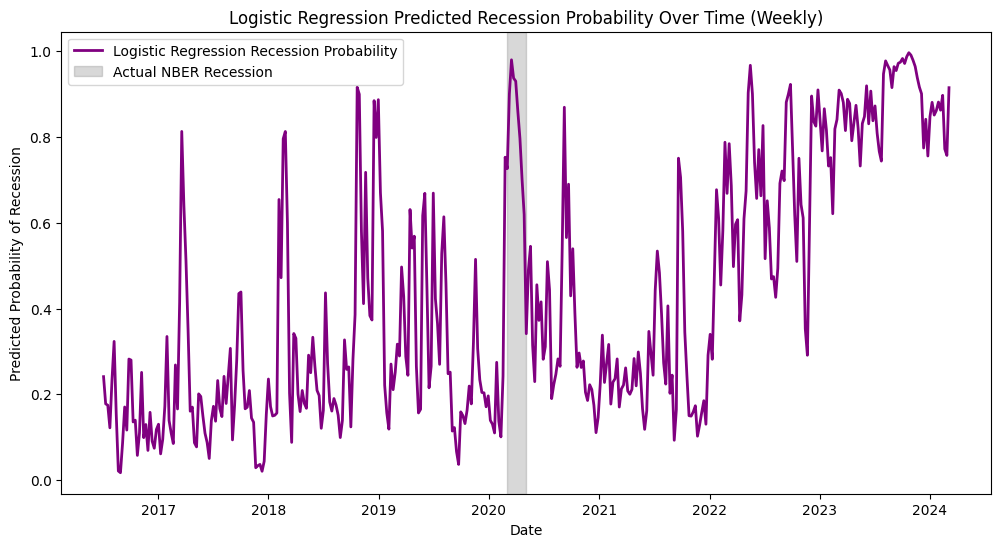

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# TRAIN THE LOGISTIC REGRESSION MODEL
# ---------------------------------------------------------
log_reg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', random_state=42)
)

log_reg_model.fit(training_x, training_y)
y_log_pred = log_reg_model.predict(testing_x)

print("\nClassification Report for Logistic Regression:")
print(classification_report(testing_y, y_log_pred))

y_log_probs_all = log_reg_model.predict_proba(testing_x)
y_recession_probs = y_log_probs_all[:, 1]

auc = roc_auc_score(testing_y, y_recession_probs)
print(f"ROC-AUC Score: {auc:.4f}")

log_proba_table = testing_data[['aligned_week']].copy()
log_proba_table['y_recession_prob'] = y_recession_probs

log_proba_table['month_start'] = log_proba_table['aligned_week'].dt.to_period('M').dt.start_time

log_proba_table = pd.merge(
    log_proba_table, 
    recession_data, 
    on='month_start', 
    how='left'
)

log_proba_table['change'] = log_proba_table['recession'].diff()

starts = log_proba_table[log_proba_table['change'] == 1]['aligned_week'].tolist()
ends = log_proba_table[log_proba_table['change'] == -1]['aligned_week'].tolist()

# Handle edge cases (recession active at the very start or end of the data block)
if log_proba_table['recession'].iloc[0] == 1:
    starts.insert(0, log_proba_table['aligned_week'].iloc[0])
if log_proba_table['recession'].iloc[-1] == 1:
    ends.append(log_proba_table['aligned_week'].iloc[-1])

# ---------------------------------------------------------
# PLOT THE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(log_proba_table['aligned_week'], log_proba_table['y_recession_prob'], 
         label='Logistic Regression Recession Probability', color='purple', linewidth=2)
for i, (s, e) in enumerate(zip(starts, ends)):
    label = 'Actual NBER Recession' if i == 0 else ""
    plt.axvspan(s, e, color='gray', alpha=0.3, label=label)

plt.title('Logistic Regression Predicted Recession Probability Over Time (Weekly)')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()
plt.show()